# Lecture 3: Can airport weather fill the gaps in Islamabad air-quality data?

**The story:** The Pak-EPA air-quality record contains PM2.5 and other pollutants across 2018–2026. Temperature and humidity are present in earlier records but disappear from later ones. We have another weather series from Meteostat station 41571, labelled Islamabad Airport. Can it help fill the missing weather fields?

We will use **pandas and SQL** to inspect the two tables, join them by date, compare temperature and humidity where both exist, plot their differences, and test how filling gaps changes pollutant–weather correlations. A strong correlation between weather series alone does not prove that individual days agree or that substitution is scientifically valid.

In [1]:
# Google Colab only: download this lecture's data and helper files, then work inside that folder.
# Running locally? Start Jupyter in the lecture folder and this cell does nothing.
import os, sys
if 'google.colab' in sys.modules and not os.path.exists('requirements.txt'):
    !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/DrFarrukh/teaching.git /content/teaching
    !git -C /content/teaching sparse-checkout set courses/tools-and-tech-in-data-science/lectures/lecture-03
    os.chdir('/content/teaching/courses/tools-and-tech-in-data-science/lectures/lecture-03')
    !pip -q install -r requirements.txt
    print('Working folder:', os.getcwd())

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [3]:
ROOT = Path.cwd()
if not (ROOT / 'data' / 'epa_daily.csv').exists():
    ROOT = ROOT.parent
assert (ROOT / 'data' / 'epa_daily.csv').exists(), 'Start Jupyter in the Lecture 3 folder.'
import sys
sys.path.insert(0, str(ROOT))
import lecture_visuals as visuals

In [4]:
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16, 'figure.dpi': 110})
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#176B87', '#D66A2C'])

## Begin with the measurement question

“Where did these temperature and humidity readings come from?” The Pak-EPA file does not include monitor coordinates, but Pak-EPA publications describe its fixed station in **H-8/2**. The research weather download uses Meteostat station **41571, Islamabad Airport**. The sites may experience different conditions, and a daily mean may hide differences in measurement timing.

**Our decision question:** Are the airport values close enough to the EPA values on days where both exist to use as a *documented, provisional proxy* for later missing EPA weather?

Before any code, keep four tests in mind: **coverage → date match → agreement → effect on analysis**.

Sources: [Pak-EPA yearbook](https://environment.gov.pk/SiteImage/Publication/Year%20Book%202022-23.pdf) and [Meteostat station 41571](https://meteostat.net/en/station/41571). Exact Pak-EPA sensor coordinates and measurement protocol are not present in these two teaching CSVs.

In [5]:
# Natural Earth country boundaries (public domain) are included in this folder.
shp = "ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp"
assert Path(shp).exists(), 'Start Jupyter in the Lecture 3 folder.'

In [6]:
from cartopy.io import shapereader

shp = "ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp"
pak_geom = [r.geometry for r in shapereader.Reader(shp).records()
            if r.attributes["ADMIN"] == "Pakistan"][0]
print(pak_geom.bounds)   # should be roughly (60.9, 23.7, 77.8, 37.1)

(60.844378703000075, 23.694525458000044, 77.04897098800006, 37.05448354100004)


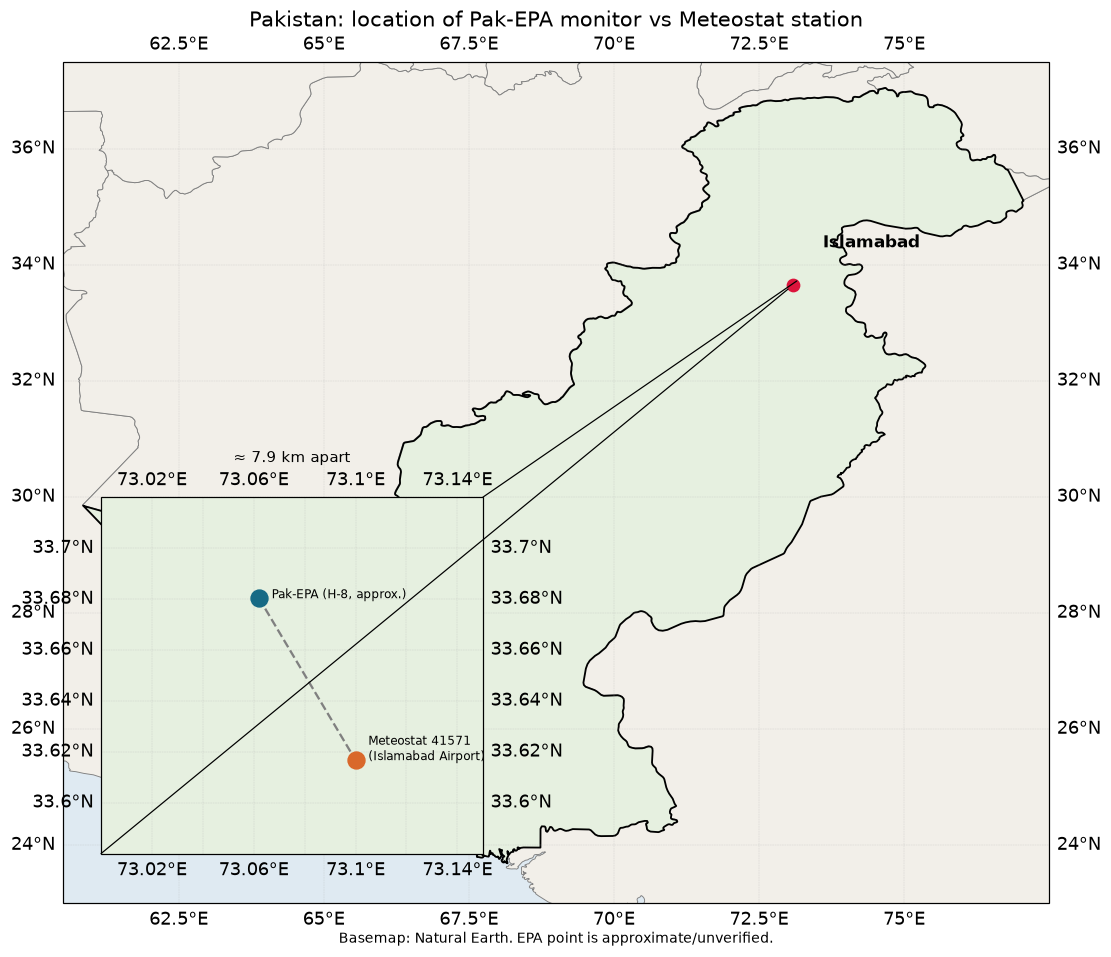

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.io import shapereader
from matplotlib.patches import ConnectionPatch
import numpy as np

# --- Your coordinates (lat, lon) ---
epa = {"name": "Pak-EPA: approx. H-8 area\nMonitor reported in H-8/2",
       "lat": 33.68031, "lon": 73.06205, "color": "#166a85"}
met = {"name": "Meteostat 41571: Islamabad Airport\nelev. 507 m",
       "lat": 33.6167, "lon": 73.1000, "color": "#d9682b"}
points = [epa, met]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = p2 - p1
    dl = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

dist_km = haversine(epa["lat"], epa["lon"], met["lat"], met["lon"])

# --- Load boundaries from your local shapefile (no download) ---
shp = "ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp"
records = list(shapereader.Reader(shp).records())
pak_geom = [r.geometry for r in records if r.attributes["ADMIN"] == "Pakistan"][0]
other_geoms = [r.geometry for r in records if r.attributes["ADMIN"] != "Pakistan"]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 9))
ax = fig.add_axes([0.05, 0.05, 0.9, 0.85], projection=proj)
ax.set_extent([60.5, 77.5, 23, 37.5], crs=proj)

# Background = "sea/outside", neighbours in light grey, Pakistan in green
ax.set_facecolor("#dfeaf2")
ax.add_geometries(other_geoms, crs=proj, facecolor="#f2efe9",
                  edgecolor="gray", linewidth=0.6)
ax.add_geometries([pak_geom], crs=proj, facecolor="#e6f0e0",
                  edgecolor="black", linewidth=1.2)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")

# Main map marker
ax.plot(73.08, 33.65, "o", color="crimson", ms=8, transform=proj, zorder=5)
ax.text(73.6, 34.3, "Islamabad", transform=proj, fontsize=11, weight="bold")

# --- Inset zoom ---
axins = fig.add_axes([0.08, 0.10, 0.36, 0.36], projection=proj)
axins.set_extent([73.00, 73.15, 33.58, 33.72], crs=proj)
axins.set_facecolor("#e6f0e0")   # inside Pakistan
axins.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")

for p in points:
    axins.plot(p["lon"], p["lat"], "o", color=p["color"], ms=11,
               transform=proj, zorder=5)
axins.plot([epa["lon"], met["lon"]], [epa["lat"], met["lat"]],
           "--", color="gray", transform=proj)
axins.text(epa["lon"]+0.005, epa["lat"], "Pak-EPA (H-8, approx.)",
           transform=proj, fontsize=8)
axins.text(met["lon"]+0.005, met["lat"], "Meteostat 41571\n(Islamabad Airport)",
           transform=proj, fontsize=8)
axins.set_title(f"≈ {dist_km:.1f} km apart", fontsize=10)

# Connector lines from main-map box to inset
for corner_main, corner_ins in [((73.00, 33.58), (0, 0)), ((73.15, 33.72), (1, 1))]:
    con = ConnectionPatch(xyA=corner_ins, coordsA=axins.transAxes,
                          xyB=corner_main, coordsB=ax.transData,
                          color="black", lw=0.8)
    fig.add_artist(con)

ax.set_title("Pakistan: location of Pak-EPA monitor vs Meteostat station",
             fontsize=14)
fig.text(0.5, 0.01,
         "Basemap: Natural Earth. EPA point is approximate/unverified.",
         ha="center", fontsize=9)
plt.savefig("pakistan_map.png", dpi=200, bbox_inches="tight")
plt.show()

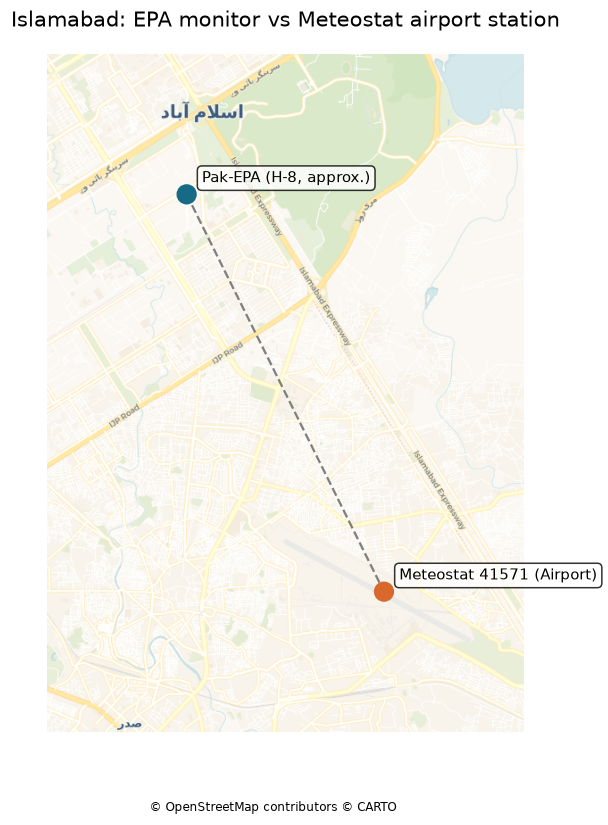

In [8]:
import os
import geopandas as gpd
from shapely.geometry import Point
import contextily as cx
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

pts = gpd.GeoDataFrame(
    {"name": ["Pak-EPA (H-8, approx.)", "Meteostat 41571 (Airport)"],
     "color": ["#166a85", "#d9682b"]},
    geometry=[Point(73.06205, 33.68031), Point(73.1000, 33.6167)],
    crs="EPSG:4326",
).to_crs(epsg=3857)

# Padded bounds in Web Mercator meters
minx, miny, maxx, maxy = pts.total_bounds
pad = 3000
west, south, east, north = minx - pad, miny - pad, maxx + pad, maxy + pad

# The basemap is saved beside the notebook; download tiles only if it is missing.
tif_path = "islamabad_basemap.tif"
if not os.path.exists(tif_path):
    cx.bounds2raster(west, south, east, north, path=tif_path, zoom=13,
                     source=cx.providers.CartoDB.Voyager, ll=False)

# Plot from the saved file
fig, ax = plt.subplots(figsize=(9, 8))

with rasterio.open(tif_path) as src:
    show(src, ax=ax)

pts.plot(ax=ax, color=pts["color"], markersize=150, zorder=5)
ax.plot(pts.geometry.x, pts.geometry.y, "--", color="gray", zorder=4)

for _, r in pts.iterrows():
    ax.annotate(r["name"], (r.geometry.x, r.geometry.y),
                xytext=(10, 8), textcoords="offset points", fontsize=10,
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))

ax.set_xlim(west, east)
ax.set_ylim(south, north)
ax.set_axis_off()
ax.set_title("Islamabad: EPA monitor vs Meteostat airport station", fontsize=14)
fig.text(0.5, 0.02, "© OpenStreetMap contributors © CARTO", ha="center", fontsize=8)
plt.savefig("islamabad_zoom.png", dpi=200, bbox_inches="tight")
plt.show()

In [9]:
# visuals.location_chart()

The sites are separated geographically. Would distance alone tell us the temperature error? The H-8 point is approximate, so the distance is illustrative, not a surveyed sensor separation.

## Relational data and a short SQL refresher

**Table:** rows and named columns. **Grain:** what one row represents. `epa_daily` has one air-quality record per reported date. `weather_daily` has one Meteostat daily record per reported date. **Candidate key:** `date` is unique within each teaching file; we will check this. A CSV does not enforce a primary key.

**Join:** pair rows when `epa_daily.date = weather_daily.date`. A `LEFT JOIN` keeps every EPA date, even if Meteostat has no matching date. A duplicate weather date would multiply an EPA row. `NULL` means an absent value; it is not zero.

Use four visible dates first. EPA: Jan 1, 2, 3, 4. Weather: Jan 1, 2, 4. Predict the left-join result before running the next cell.

In [10]:
con = duckdb.connect(':memory:')
con.execute("CREATE TABLE small_epa(date DATE, pm25 DOUBLE)")
con.execute("INSERT INTO small_epa VALUES ('2023-01-01',40),('2023-01-02',55),('2023-01-03',60),('2023-01-04',30)")
con.execute("CREATE TABLE small_weather(date DATE, temp DOUBLE)")
con.execute("INSERT INTO small_weather VALUES ('2023-01-01',12),('2023-01-02',10),('2023-01-04',14)")

In [11]:
display(con.sql('SELECT * FROM small_epa ORDER BY date').df())
display(con.sql('SELECT * FROM small_weather ORDER BY date').df())

,date,pm25
0,2023-01-01,40.0
1,2023-01-02,55.0
2,2023-01-03,60.0
3,2023-01-04,30.0


,date,temp
0,2023-01-01,12.0
1,2023-01-02,10.0
2,2023-01-04,14.0


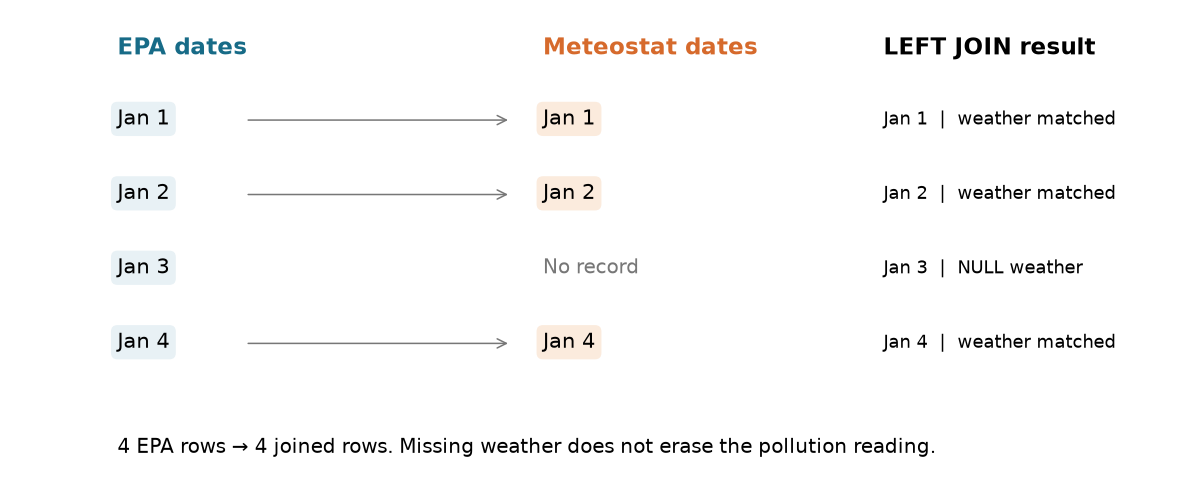

In [12]:
visuals.join_picture()

Trace the Jan 3 row. Why does it survive even though there is no weather record?

`SELECT` chooses output columns, `FROM` names the table, and `ORDER BY` controls display. `WHERE` filters rows. The query below asks for high-PM2.5 days in our tiny table.

In [13]:
con.sql('SELECT date, pm25 FROM small_epa WHERE pm25 >= 50 ORDER BY date').df()

,date,pm25
0,2023-01-02,55.0
1,2023-01-03,60.0


`LEFT JOIN` keeps the left table's four dates. The `ON` condition says how records match. Ask: Which row will have `NULL` temperature?

In [14]:
con.sql('''
SELECT e.date, e.pm25, w.temp
FROM small_epa e LEFT JOIN small_weather w ON e.date = w.date
ORDER BY e.date
''').df()

,date,pm25,temp
0,2023-01-01,40.0,12.0
1,2023-01-02,55.0,10.0
2,2023-01-03,60.0,NaN
3,2023-01-04,30.0,14.0


An `INNER JOIN` would drop Jan 3. `COUNT(*)` counts rows; `AVG` ignores missing values. `GROUP BY` changes the output grain to one row per group. We will use these ideas on the full files.

In [15]:
display(con.sql('SELECT COUNT(*) AS rows, AVG(pm25) AS mean_pm25 FROM small_epa').df())
display(con.sql('SELECT COUNT(*) AS matched_rows FROM small_epa e JOIN small_weather w ON e.date=w.date').df())

,rows,mean_pm25
0,4,46.25


,matched_rows
0,3


## What changed in the EPA file?

The prepared CSV keeps the original EPA temperature, humidity, NO2, SO2, and PM2.5, with ISO dates and clear column names. The Meteostat CSV keeps only daily mean temperature and humidity. The source files remain available in `data/`.

**Prediction:** If the original EPA weather columns disappear in later years, what should a year-by-year count look like?

In [16]:
raw_epa = pd.read_csv(ROOT / 'data' / 'new_data.csv', dtype='string')
display(raw_epa.head(2))
display(raw_epa.tail(2))

,Date,Temperature,Humidity,NO2,SO2,PM2.5
0,17/05/2018,31.57,27.36,18.36,18.32,14.32
1,18/05/2018,30.83,23.31,17.31,20.23,13.21


,Date,Temperature,Humidity,NO2,SO2,PM2.5
2553,30/08/2026,<NA>,<NA>,4.1,16.4,38.1
2554,31/08/2026,<NA>,<NA>,4.6,16.6,31.4


The consolidated source keeps the same six CSV headings, but later report periods have blank temperature and humidity cells. Its dates are day-first text. The clean teaching CSV standardizes them to ISO dates while preserving the blanks. This makes the input change visible before analysis.

In [17]:
epa_path = ROOT / 'data' / 'epa_daily.csv'
weather_path = ROOT / 'data' / 'meteostat_temp_humidity_daily.csv'
epa = pd.read_csv(epa_path, parse_dates=['date'])
weather = pd.read_csv(weather_path, parse_dates=['date'])
display(epa.head(3))
display(weather.head(3))

,date,epa_temperature_c,epa_humidity_pct,no2_ug_m3,so2_ug_m3,pm25_ug_m3
0,2018-05-17,31.57,27.36,18.36,18.32,14.32
1,2018-05-18,30.83,23.31,17.31,20.23,13.21
2,2018-05-21,29.30,26.52,16.32,14.32,14.21


,date,meteostat_temperature_c,meteostat_humidity_pct
0,2018-05-17,29.323077,37.846154
1,2018-05-18,29.281818,40.227273
2,2018-05-19,27.791667,34.625000


In [18]:
print('EPA rows:', len(epa), 'unique dates:', epa.date.nunique())
print('Meteostat rows:', len(weather), 'unique dates:', weather.date.nunique())
assert len(epa) == epa.date.nunique() == 2555
assert len(weather) == weather.date.nunique() == 2946

EPA rows: 2555 unique dates: 2555
Meteostat rows: 2946 unique dates: 2946


In [19]:
epa['year'] = epa.date.dt.year
coverage = epa.groupby('year')[['epa_temperature_c','epa_humidity_pct','pm25_ug_m3']].count()
display(coverage)

,epa_temperature_c,epa_humidity_pct,pm25_ug_m3
year,,,
2018,72,72,72
2019,227,227,227
2020,365,365,365
2021,365,365,365
2022,365,365,365
2023,365,365,365
2024,121,121,181
2025,0,0,357
2026,0,0,243


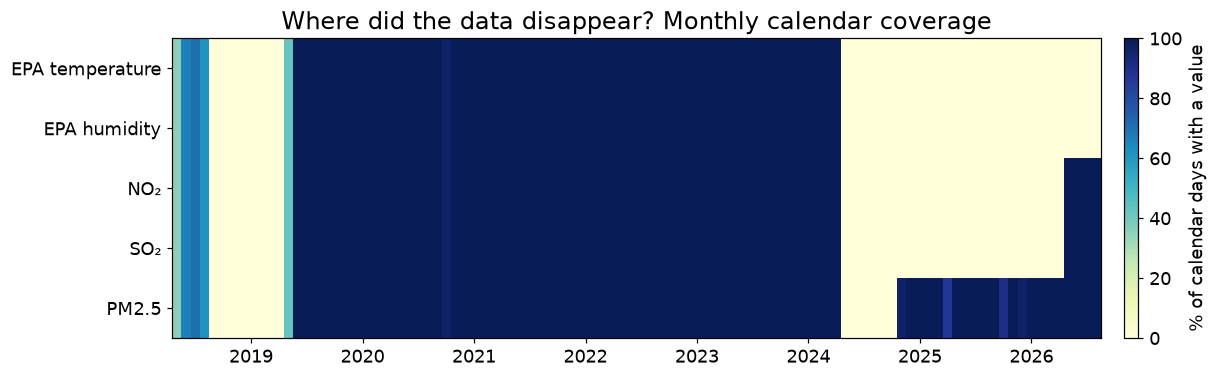

In [20]:
visuals.monthly_coverage(epa)

**Discuss the picture:** Which fields disappear together? Blank weather in later reports is a different problem from a missing calendar date.

EPA temperature and humidity have **no values in 2025 or 2026**. Earlier years are not uniformly complete either. The PM2.5 record also has 15 blank values. Missing weather and missing pollutant are different problems.

Make the coverage change visible. The bars count reported values, not percentages of a complete year; 2018, 2019, 2024, and 2026 have partial date coverage in this file.

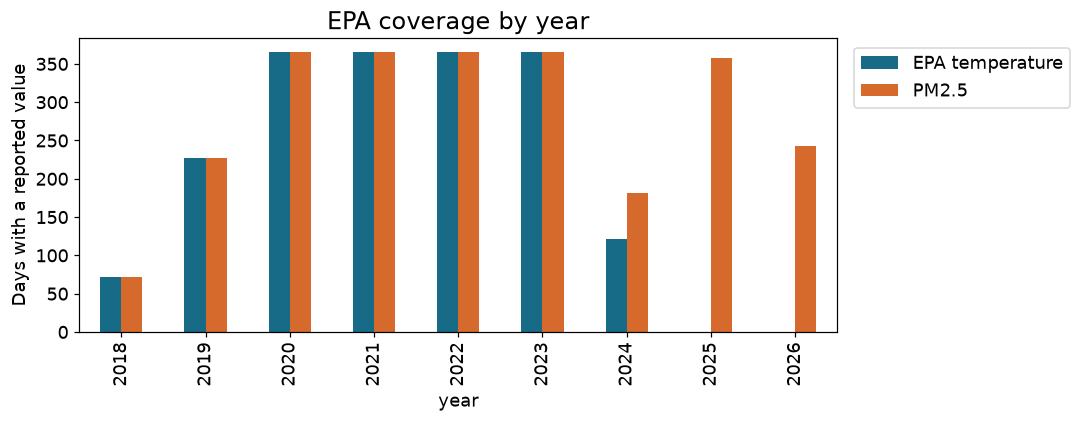

In [21]:
ax = coverage[['epa_temperature_c','pm25_ug_m3']].plot.bar(figsize=(10,4))
ax.legend(['EPA temperature','PM2.5'], loc='upper left', bbox_to_anchor=(1.01,1))
plt.ylabel('Days with a reported value')
plt.title('EPA coverage by year')
plt.tight_layout()
plt.show()

## Bring Meteostat into the same daily table

In pandas, `merge` pairs dates. In SQL, `JOIN ... ON` does the same. We preserve EPA dates with a left join. The `validate='one_to_one'` option checks that dates are unique on both sides.

Before running, predict the output count. The inputs have 2,555 EPA dates and 2,946 weather dates; a left join does **not** add weather-only dates.

In [22]:
joined = epa.merge(weather, on='date', how='left', validate='one_to_one', indicator=True)
display(joined['_merge'].value_counts())
assert len(joined) == 2555
assert (joined['_merge'] == 'both').sum() == 2472

_merge
both          2472
left_only       83
right_only       0
Name: count, dtype: int64

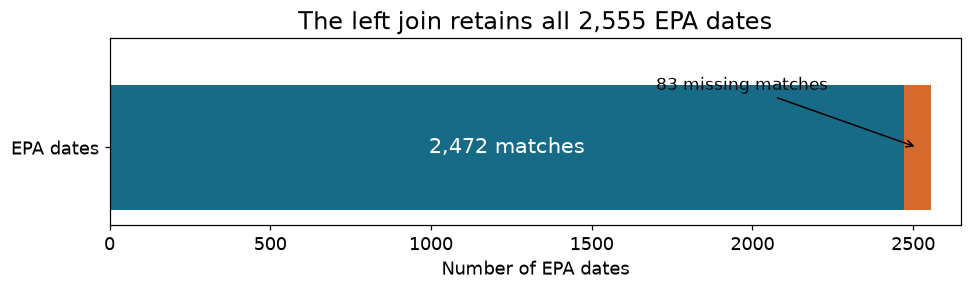

In [23]:
visuals.match_counts(joined)

A successful join preserves 2,555 EPA dates, but that does not mean all dates have weather.

In [24]:
display(joined.loc[joined['_merge']=='left_only', ['date','pm25_ug_m3']].head(8))
print('EPA dates without Meteostat weather:', (joined['_merge']=='left_only').sum())

,date,pm25_ug_m3
92,2019-06-01,32.12
93,2019-06-02,30.60
94,2019-06-03,30.18
95,2019-06-04,30.91
96,2019-06-05,30.74
97,2019-06-06,29.41
98,2019-06-07,29.24
99,2019-06-08,28.35


EPA dates without Meteostat weather: 83


### CSV to SQL tables

DuckDB reads the two CSVs and creates in-memory tables. `DESCRIBE` shows the inferred SQL types. `DATE` allows real date comparisons; `DOUBLE` stores numerical weather and pollutant values.

In [25]:
con.execute(f"CREATE TABLE epa_daily AS SELECT * FROM read_csv_auto('{epa_path.as_posix()}')")
con.execute(f"CREATE TABLE weather_daily AS SELECT * FROM read_csv_auto('{weather_path.as_posix()}')")
display(con.sql('DESCRIBE epa_daily').df())

,column_name,column_type,null,key,default,extra
0,date,DATE,YES,None,None,None
1,epa_temperature_c,DOUBLE,YES,None,None,None
2,epa_humidity_pct,DOUBLE,YES,None,None,None
3,no2_ug_m3,DOUBLE,YES,None,None,None
4,so2_ug_m3,DOUBLE,YES,None,None,None
5,pm25_ug_m3,DOUBLE,YES,None,None,None


In [26]:
con.sql('''
SELECT COUNT(*) AS rows, COUNT(DISTINCT date) AS unique_dates,
       COUNT(epa_temperature_c) AS days_with_epa_temperature
FROM epa_daily
''').df()

,rows,unique_dates,days_with_epa_temperature
0,2555,2555,1880


`GROUP BY` produces one row per year. Compare the SQL counts with the pandas coverage table. `COUNT(epa_temperature_c)` ignores missing values.

In [27]:
con.sql('''
SELECT YEAR(date) AS year, COUNT(*) AS reported_days,
       COUNT(epa_temperature_c) AS temperature_days
FROM epa_daily GROUP BY YEAR(date) ORDER BY year
''').df()

,year,reported_days,temperature_days
0,2018,75,72
1,2019,231,227
2,2020,365,365
3,2021,365,365
4,2022,365,365
5,2023,365,365
6,2024,181,121
7,2025,365,0
8,2026,243,0


The SQL join keeps one EPA row per date only if weather dates are unique. Predict the four counts: EPA rows, joined rows, distinct joined dates, and weather matches.

In [28]:
con.sql('''
SELECT COUNT(*) AS joined_rows, COUNT(DISTINCT e.date) AS unique_epa_dates,
       COUNT(w.date) AS weather_matches, COUNT(*)-COUNT(w.date) AS no_weather
FROM epa_daily e LEFT JOIN weather_daily w ON e.date = w.date
''').df()

,joined_rows,unique_epa_dates,weather_matches,no_weather
0,2555,2555,2472,83


In [29]:
con.sql('''
SELECT e.date, e.pm25_ug_m3, e.epa_temperature_c,
       w.meteostat_temperature_c, e.epa_humidity_pct, w.meteostat_humidity_pct
FROM epa_daily e LEFT JOIN weather_daily w ON e.date = w.date
ORDER BY e.date LIMIT 8
''').df()

,date,pm25_ug_m3,epa_temperature_c,meteostat_temperature_c,epa_humidity_pct,meteostat_humidity_pct
0,2018-05-17,14.32,31.57,29.323077,27.36,37.846154
1,2018-05-18,13.21,30.83,29.281818,23.31,40.227273
2,2018-05-21,14.21,29.30,29.979167,26.52,30.041667
3,2018-05-22,13.08,30.35,30.279167,25.63,29.583333
4,2018-05-23,13.86,30.92,30.104167,25.32,30.500000
5,2018-05-24,14.21,31.57,30.608696,26.31,29.652174
6,2018-05-25,17.20,32.53,31.978261,24.22,26.782609
7,2018-05-28,27.32,31.84,32.958333,24.08,25.833333


## Do the two weather sources agree?

Use only dates where **both** sources recorded temperature and humidity. This gives a fair same-day comparison. The overlap contains 1,797 paired days. First inspect actual values, then calculate three different kinds of evidence:

- **Correlation:** whether warmer days in one series tend to be warmer in the other. It does not measure equality.
- **Bias:** the average Meteostat-minus-EPA difference; positive means Meteostat tends to be higher.
- **MAE:** the mean absolute daily difference, in °C or percentage points. It makes the typical size of disagreement understandable.

There is no universal threshold that makes the two stations interchangeable. We will interpret the evidence for this exploratory analysis.

In [30]:
paired = joined.dropna(subset=['epa_temperature_c','epa_humidity_pct',
                               'meteostat_temperature_c','meteostat_humidity_pct']).copy()
print('Paired weather days:', len(paired))
assert len(paired) == 1797
display(paired[['date','epa_temperature_c','meteostat_temperature_c',
                'epa_humidity_pct','meteostat_humidity_pct']].head())

Paired weather days: 1797


,date,epa_temperature_c,meteostat_temperature_c,epa_humidity_pct,meteostat_humidity_pct
0,2018-05-17,31.57,29.323077,27.36,37.846154
1,2018-05-18,30.83,29.281818,23.31,40.227273
2,2018-05-21,29.30,29.979167,26.52,30.041667
3,2018-05-22,30.35,30.279167,25.63,29.583333
4,2018-05-23,30.92,30.104167,25.32,30.500000


In [31]:
paired['temp_difference'] = paired.meteostat_temperature_c - paired.epa_temperature_c
paired['humidity_difference'] = paired.meteostat_humidity_pct - paired.epa_humidity_pct
display(paired[['temp_difference','humidity_difference']].describe().round(2))

,temp_difference,humidity_difference
count,1797.00,1797.00
mean,-0.75,2.73
std,3.07,13.64
min,-13.55,-59.46
25%,-2.47,-5.58
50%,-0.51,2.42
75%,1.12,11.42
max,17.96,50.08


`CORR` and `AVG(ABS(...))` let us calculate the same evidence in SQL. Read the two queries line by line. Which number measures alignment of highs and lows, and which measures the size of a daily substitution error.

In [32]:
con.sql('''
SELECT COUNT(*) AS paired_days,
       CORR(e.epa_temperature_c,w.meteostat_temperature_c) AS correlation,
       AVG(w.meteostat_temperature_c-e.epa_temperature_c) AS bias_c,
       AVG(ABS(w.meteostat_temperature_c-e.epa_temperature_c)) AS mae_c
FROM epa_daily e JOIN weather_daily w ON e.date=w.date
WHERE e.epa_temperature_c IS NOT NULL AND w.meteostat_temperature_c IS NOT NULL
''').df().round(3)

,paired_days,correlation,bias_c,mae_c
0,1797,0.927,-0.754,2.334


In [33]:
con.sql('''
SELECT COUNT(*) AS paired_days,
       CORR(e.epa_humidity_pct,w.meteostat_humidity_pct) AS correlation,
       AVG(w.meteostat_humidity_pct-e.epa_humidity_pct) AS bias_points,
       AVG(ABS(w.meteostat_humidity_pct-e.epa_humidity_pct)) AS mae_points
FROM epa_daily e JOIN weather_daily w ON e.date=w.date
WHERE e.epa_humidity_pct IS NOT NULL AND w.meteostat_humidity_pct IS NOT NULL
''').df().round(3)

,paired_days,correlation,bias_points,mae_points
0,1797,0.645,2.729,10.871


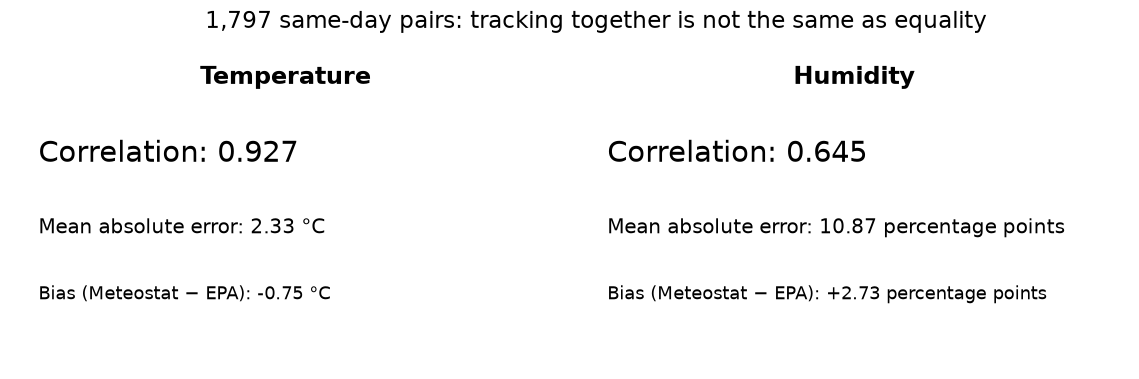

In [34]:
visuals.agreement_summary(paired)

Would you make the same substitution decision for temperature and humidity? Correlation and daily error answer different questions.

### Plot 1: do individual days sit near the equal-value line?

A scatter plot shows agreement better than correlation alone. The diagonal means exact agreement. Wide scatter around it means substitution error even when a correlation is positive.

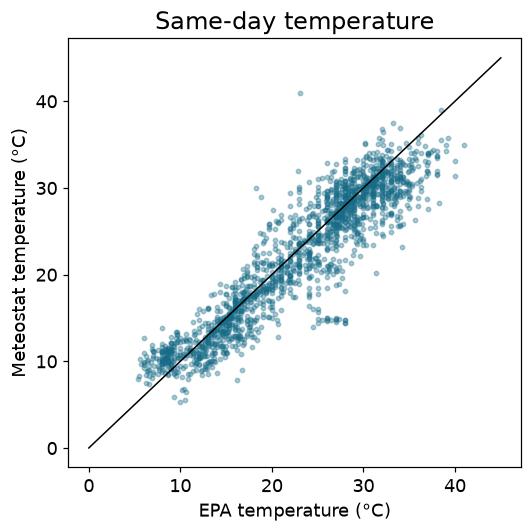

In [35]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(paired.epa_temperature_c, paired.meteostat_temperature_c, s=8, alpha=.35)
ax.plot([0,45],[0,45], color='black', linewidth=1)
ax.set(xlabel='EPA temperature (°C)', ylabel='Meteostat temperature (°C)', title='Same-day temperature')
plt.tight_layout(); plt.show()

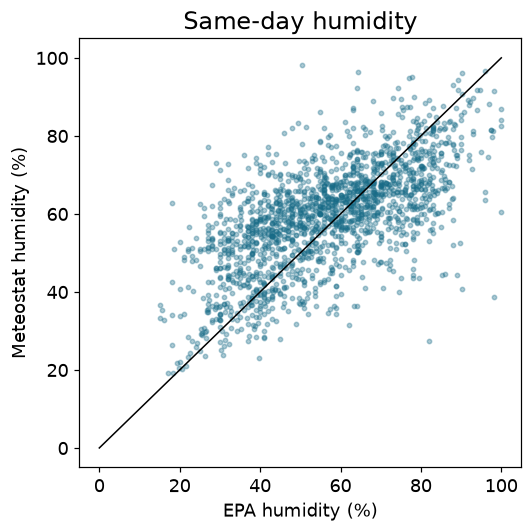

In [36]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(paired.epa_humidity_pct, paired.meteostat_humidity_pct, s=8, alpha=.35)
ax.plot([0,100],[0,100], color='black', linewidth=1)
ax.set(xlabel='EPA humidity (%)', ylabel='Meteostat humidity (%)', title='Same-day humidity')
plt.tight_layout(); plt.show()

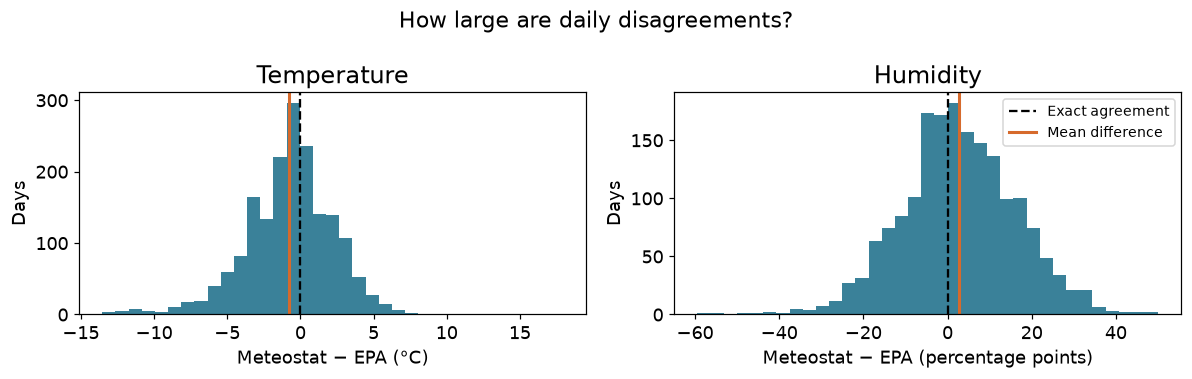

In [37]:
visuals.difference_histograms(paired)

Zero means exact agreement. How far from zero do individual days lie? Is a single average bias enough to describe the error?

### Plot 2: what happens over time?

View a short period where both series are present. Ask whether the peaks occur together and whether one series is consistently higher. A time plot helps reveal offsets and dates that merit inspection.

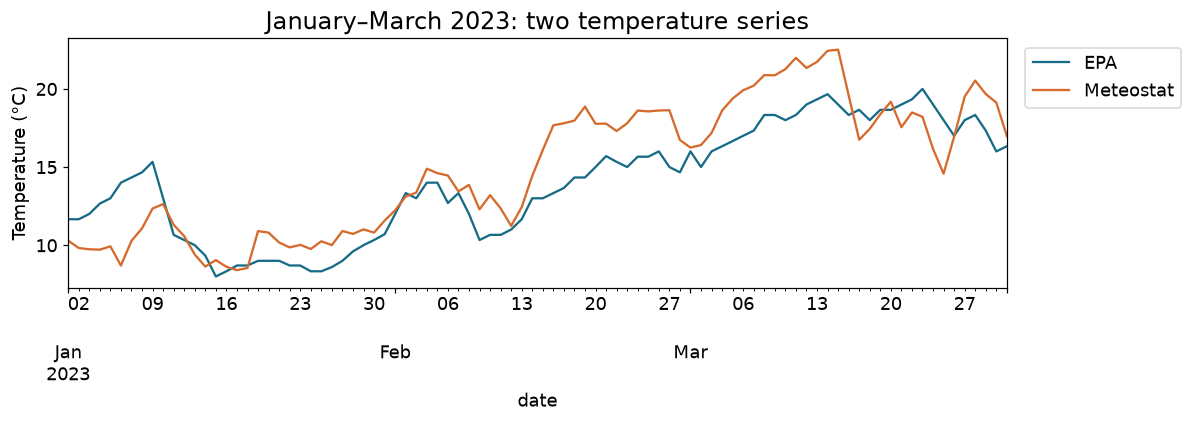

In [38]:
window = paired.loc[paired.date.between('2023-01-01','2023-03-31')]
ax = window.plot(x='date', y=['epa_temperature_c','meteostat_temperature_c'], figsize=(11,4))
ax.legend(['EPA','Meteostat'], loc='upper left', bbox_to_anchor=(1.01,1))
plt.ylabel('Temperature (°C)'); plt.title('January–March 2023: two temperature series')
plt.tight_layout(); plt.show()

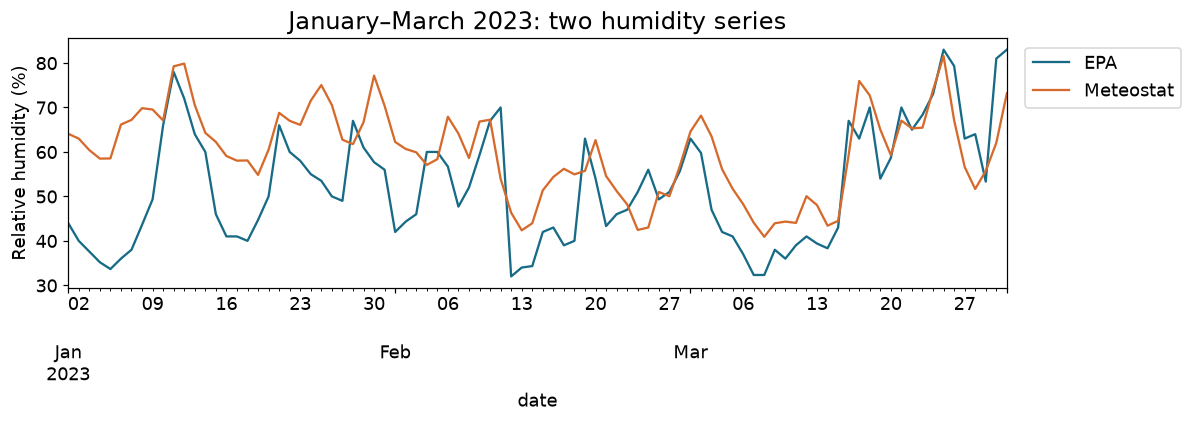

In [39]:
ax = window.plot(x='date', y=['epa_humidity_pct','meteostat_humidity_pct'], figsize=(11,4))
ax.legend(['EPA','Meteostat'], loc='upper left', bbox_to_anchor=(1.01,1))
plt.ylabel('Relative humidity (%)'); plt.title('January–March 2023: two humidity series')
plt.tight_layout(); plt.show()

Temperature tracks fairly closely, but daily differences remain material. Humidity shows weaker agreement and much larger daily differences. Do not call either source a perfect replacement. Check whether disagreement changes across years before using a proxy in later years.

In [40]:
paired['year'] = paired.date.dt.year
yearly_error = paired.groupby('year').agg(
    paired_days=('date','size'),
    temp_mae_c=('temp_difference', lambda x: x.abs().mean()),
    humidity_mae_points=('humidity_difference', lambda x: x.abs().mean()))
display(yearly_error.round(2))

,paired_days,temp_mae_c,humidity_mae_points
year,,,
2018,72,1.75,9.16
2019,144,2.49,9.43
2020,365,2.58,13.64
2021,365,1.97,11.42
2022,365,2.07,9.17
2023,365,2.53,10.28
2024,121,3.07,10.49


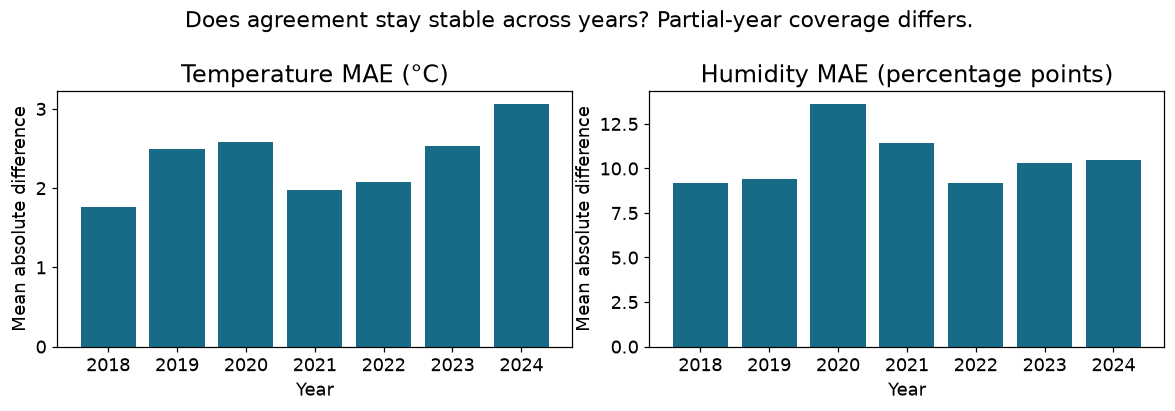

In [41]:
visuals.annual_errors(yearly_error)

**Discuss the picture:** The average error changes by year. That limits our confidence when carrying an early-period relationship into later missing periods.

## Build a transparent candidate fill

We keep the original EPA columns. We create new fields that take the EPA reading when it exists and use Meteostat only when EPA is missing. We also label the source of each value. This is a *candidate analytical dataset*, not a claim that the weather stations are identical.

How many EPA dates receive Meteostat values? How many dates remain without any temperature or humidity?

In [42]:
joined['temperature_candidate_c'] = joined.epa_temperature_c.combine_first(joined.meteostat_temperature_c)
joined['humidity_candidate_pct'] = joined.epa_humidity_pct.combine_first(joined.meteostat_humidity_pct)

In [43]:
joined['temperature_source'] = np.where(joined.epa_temperature_c.notna(), 'EPA',
                                 np.where(joined.meteostat_temperature_c.notna(), 'Meteostat', 'missing'))
joined['humidity_source'] = np.where(joined.epa_humidity_pct.notna(), 'EPA',
                              np.where(joined.meteostat_humidity_pct.notna(), 'Meteostat', 'missing'))
display(joined[['temperature_source','humidity_source']].value_counts())
assert (joined.temperature_source == 'Meteostat').sum() == 675
assert (joined.humidity_source == 'Meteostat').sum() == 675

temperature_source  humidity_source
EPA                 EPA                1880
Meteostat           Meteostat           675
Name: count, dtype: int64

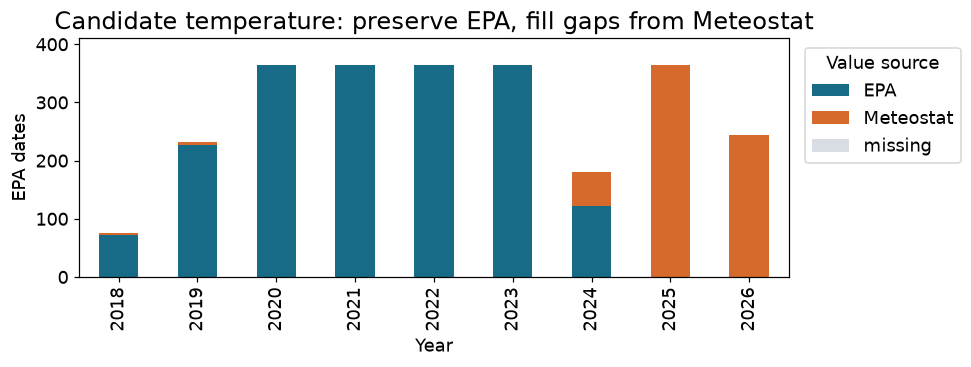

In [44]:
visuals.fill_coverage(joined)

The source of weather changes over time. Preserve that provenance when interpreting a long-term trend.

SQL has `COALESCE`: use the first non-NULL value. It expresses the same choice as pandas `combine_first`. The final column name says **candidate** so that the assumption stays visible.

In [45]:
con.sql('''
SELECT e.date, e.epa_temperature_c, w.meteostat_temperature_c,
       COALESCE(e.epa_temperature_c,w.meteostat_temperature_c) AS temperature_candidate_c
FROM epa_daily e LEFT JOIN weather_daily w ON e.date=w.date
WHERE e.epa_temperature_c IS NULL ORDER BY e.date LIMIT 8
''').df()

,date,epa_temperature_c,meteostat_temperature_c,temperature_candidate_c
0,2018-08-21,NaN,29.658333,29.658333
1,2018-08-22,NaN,30.454167,30.454167
2,2018-08-23,NaN,30.012500,30.012500
3,2019-05-18,NaN,25.600000,25.600000
4,2019-05-19,NaN,27.120833,27.120833
5,2019-05-25,NaN,26.450000,26.450000
6,2019-05-26,NaN,27.583333,27.583333
7,2024-11-02,NaN,20.941667,20.941667


In [46]:
con.sql('''
SELECT COUNT(*) AS epa_dates,
       COUNT(e.epa_temperature_c) AS epa_temperature_days,
       COUNT(COALESCE(e.epa_temperature_c,w.meteostat_temperature_c)) AS candidate_temperature_days
FROM epa_daily e LEFT JOIN weather_daily w ON e.date=w.date
''').df()

,epa_dates,epa_temperature_days,candidate_temperature_days
0,2555,1880,2555


## Did the substitution change the analysis?

**Two comparisons are needed.** First, use exactly the same overlapping days to compare pollutant correlations with EPA versus Meteostat weather. This isolates the choice of weather series. Second, compare the EPA-only sample with the larger candidate-filled sample. That second change combines the weather source change **and** the addition of later dates, so do not attribute it entirely to Meteostat.

Correlation describes association, not cause. Season and other factors can affect both weather and pollution. The aim here is to audit the proposed data substitution.

In [47]:
con.sql('''
SELECT COUNT(*) AS same_days,
       CORR(e.pm25_ug_m3,e.epa_temperature_c) AS pm25_vs_epa_temp,
       CORR(e.pm25_ug_m3,w.meteostat_temperature_c) AS pm25_vs_meteostat_temp
FROM epa_daily e JOIN weather_daily w ON e.date=w.date
WHERE e.pm25_ug_m3 IS NOT NULL AND e.epa_temperature_c IS NOT NULL
  AND w.meteostat_temperature_c IS NOT NULL
''').df().round(3)

,same_days,pm25_vs_epa_temp,pm25_vs_meteostat_temp
0,1797,-0.613,-0.612


In [48]:
con.sql('''
SELECT COUNT(*) AS same_days,
       CORR(e.pm25_ug_m3,e.epa_humidity_pct) AS pm25_vs_epa_humidity,
       CORR(e.pm25_ug_m3,w.meteostat_humidity_pct) AS pm25_vs_meteostat_humidity
FROM epa_daily e JOIN weather_daily w ON e.date=w.date
WHERE e.pm25_ug_m3 IS NOT NULL AND e.epa_humidity_pct IS NOT NULL
  AND w.meteostat_humidity_pct IS NOT NULL
''').df().round(3)

,same_days,pm25_vs_epa_humidity,pm25_vs_meteostat_humidity
0,1797,0.028,0.177


The next pandas table repeats the same-day comparison for PM2.5, NO2, and SO2. Each row uses only dates where that pollutant and **both** weather sources are present. Which weather variable changes the pollutant relationship most?

In [49]:
def same_day_correlations(pollutant):
    d = paired.dropna(subset=[pollutant])
    return {'pollutant': pollutant, 'days': len(d),
            'EPA temp': d[pollutant].corr(d.epa_temperature_c),
            'Meteostat temp': d[pollutant].corr(d.meteostat_temperature_c),
            'EPA humidity': d[pollutant].corr(d.epa_humidity_pct),
            'Meteostat humidity': d[pollutant].corr(d.meteostat_humidity_pct)}

In [50]:
pollutants = ['pm25_ug_m3','no2_ug_m3','so2_ug_m3']
same_day_results = pd.DataFrame([same_day_correlations(p) for p in pollutants])
display(same_day_results.round(3))

,pollutant,days,EPA temp,Meteostat temp,EPA humidity,Meteostat humidity
0,pm25_ug_m3,1797,-0.613,-0.612,0.028,0.177
1,no2_ug_m3,1797,-0.342,-0.379,-0.027,0.150
2,so2_ug_m3,1797,-0.503,-0.500,-0.191,0.064


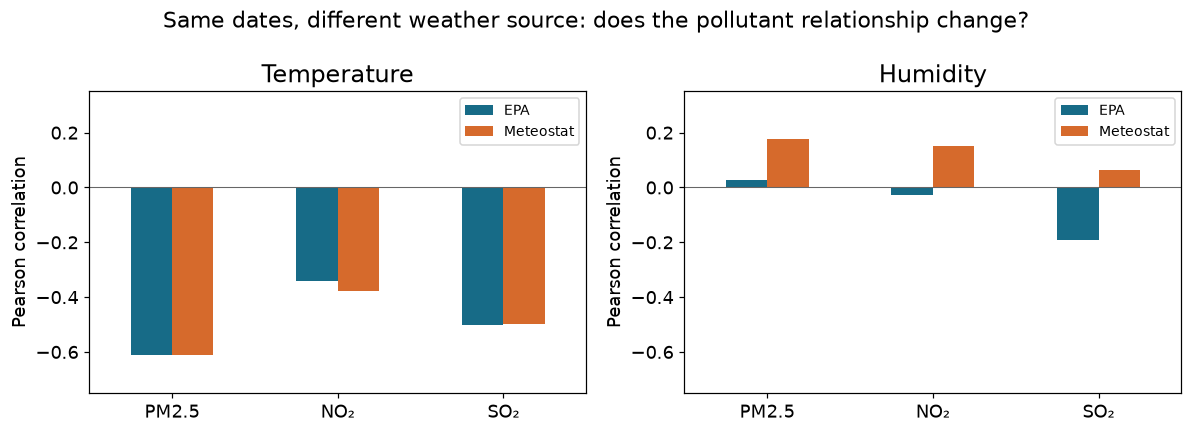

In [51]:
visuals.same_day_correlations_plot(same_day_results)

These bars use the same dates for each pollutant. Humidity can change the apparent association even without adding any new days.

Now compare the available EPA-only sample with the candidate-filled sample. We report the number of dates beside every correlation. The candidate sample is larger, so a change in correlation is **not** a clean test of replacement accuracy.

In [52]:
def before_after(pollutant, original, candidate):
    before = joined.dropna(subset=[pollutant, original])
    after = joined.dropna(subset=[pollutant, candidate])
    return {'pollutant': pollutant, 'original_days': len(before),
            'original_r': before[pollutant].corr(before[original]),
            'candidate_days': len(after),
            'candidate_r': after[pollutant].corr(after[candidate])}

In [53]:
temperature_results = pd.DataFrame([
    before_after(p,'epa_temperature_c','temperature_candidate_c') for p in pollutants])
display(temperature_results.round(3))

,pollutant,original_days,original_r,candidate_days,candidate_r
0,pm25_ug_m3,1880,-0.605,2540,-0.564
1,no2_ug_m3,1880,-0.338,2003,-0.359
2,so2_ug_m3,1880,-0.517,2003,-0.522


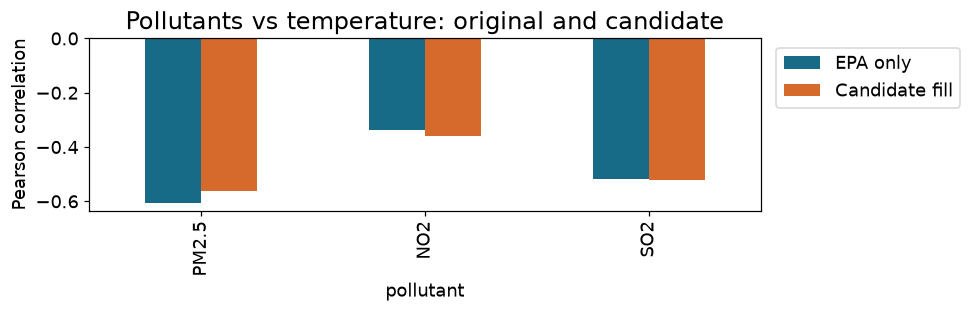

In [54]:
ax = temperature_results.assign(pollutant=['PM2.5','NO2','SO2']).plot.bar(
    x='pollutant', y=['original_r','candidate_r'], figsize=(9,3))
ax.legend(['EPA only','Candidate fill'], loc='upper left', bbox_to_anchor=(1.01,1))
plt.ylabel('Pearson correlation'); plt.title('Pollutants vs temperature: original and candidate')
plt.tight_layout(); plt.show()

In [55]:
humidity_results = pd.DataFrame([
    before_after(p,'epa_humidity_pct','humidity_candidate_pct') for p in pollutants])
display(humidity_results.round(3))

,pollutant,original_days,original_r,candidate_days,candidate_r
0,pm25_ug_m3,1880,0.030,2540,0.026
1,no2_ug_m3,1880,-0.025,2003,-0.034
2,so2_ug_m3,1880,-0.160,2003,-0.153


The same broad before/after comparison can be written in SQL using `COALESCE`. This is a useful syntax check; use the pandas tables above for the paired sample sizes.

In [56]:
con.sql('''
SELECT CORR(e.pm25_ug_m3,e.epa_temperature_c) AS original_temp_r,
       CORR(e.pm25_ug_m3,COALESCE(e.epa_temperature_c,w.meteostat_temperature_c)) AS candidate_temp_r,
       CORR(e.pm25_ug_m3,e.epa_humidity_pct) AS original_humidity_r,
       CORR(e.pm25_ug_m3,COALESCE(e.epa_humidity_pct,w.meteostat_humidity_pct)) AS candidate_humidity_r
FROM epa_daily e LEFT JOIN weather_daily w ON e.date=w.date
''').df().round(3)

,original_temp_r,candidate_temp_r,original_humidity_r,candidate_humidity_r
0,-0.605,-0.564,0.03,0.026


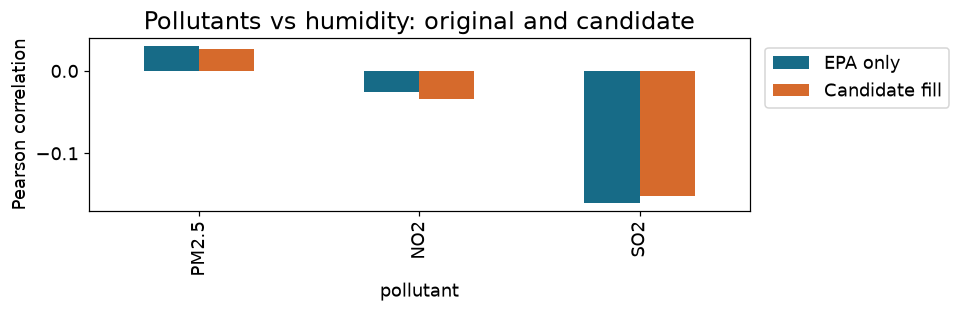

In [57]:
ax = humidity_results.assign(pollutant=['PM2.5','NO2','SO2']).plot.bar(
    x='pollutant', y=['original_r','candidate_r'], figsize=(9,3))
ax.legend(['EPA only','Candidate fill'], loc='upper left', bbox_to_anchor=(1.01,1))
plt.ylabel('Pearson correlation'); plt.title('Pollutants vs humidity: original and candidate')
plt.tight_layout(); plt.show()

If the temperature–PM2.5 correlation is similar when both weather sources are compared on identical days, that supports using Meteostat temperature for a cautious exploratory extension. Humidity agrees less well, and its pollutant correlations can change substantially even on the same days. Separate decisions for temperature and humidity may be warranted. Neither correlation table establishes causation or proves a proxy is valid for unobserved future days.

## Decision 

“Meteostat temperature is promising for exploratory gap filling, subject to the observed daily errors and station-location limitation. Meteostat humidity requires stronger caution because same-day agreement is weaker. Preserve original EPA readings, mark substituted values, and report results both with and without the candidate fill.”

1. What is the grain and key of each input table?
2. Why does a left join produce 2,555 rows and 83 missing weather matches?
3. Why can correlation be high even when daily temperatures differ by several degrees?
4. What does `COALESCE(EPA, Meteostat)` do, and why do we keep a source label?
5. Why do we compare pollutant correlations on both identical days and the expanded sample?

In [58]:
assert len(joined) == joined.date.nunique() == 2555
assert joined.temperature_candidate_c.notna().sum() == 2555
assert joined.humidity_candidate_pct.notna().sum() == 2555
print('Final checks passed: unique EPA dates, transparent candidate weather, original columns retained.')
con.close()

Final checks passed: unique EPA dates, transparent candidate weather, original columns retained.
